In [1]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# System Paths
RESULTS_DIR = Path("../../ofat_results")

# --- Model Analysis Config ---
TARGET_METRIC = "theil_index"
OUTPUT_IMAGE = f"ofat_sensitivity_analysis_{TARGET_METRIC}.png"

# --- Agent Analysis Dynamics Config ---
# Choose which parameter and specific value step to analyze the micro-dynamics for
TARGET_PARAM_NAME = "risk_aversion_max"  # Use string to perfectly match the folder name
TARGET_PARAM_VALUE = "0.99"  # Use string to perfectly match the folder name

# Dynamically scan the folders matching this specific parameter scenario
AGENT_FILE_PATTERN = f"../../ofat_results/{TARGET_PARAM_NAME}/{TARGET_PARAM_VALUE}/run_*/agents_run_*.csv"

# Quantile binning settings
NUM_QUANTILES = 10
QUANTILE_LABELS = [f"Q{i+1}" for i in range(NUM_QUANTILES)]

# Visual Styling Configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 300

In [3]:
# Discover all generated model run CSV files
csv_files = sorted(list(RESULTS_DIR.glob("**/model_run_*.csv")))
total_files = len(csv_files)

print(f"Status: OK")
print(f"Data Directory: {RESULTS_DIR.resolve()}")
print(f"Total Simulation Files Found: {total_files}")

# Peak at the first path structure to verify naming conventions match expectation
if total_files > 0:
    print(f"Sample Path Structure: {csv_files[0]}")
else:
    print("WARNING: No data found. Check if simulation pipeline completed successfully.")

Status: OK
Data Directory: /var/home/rick/Studies/Masters/ABM/ABM_Gentrification/ofat_results
Total Simulation Files Found: 650
Sample Path Structure: ../../ofat_results/affordability_share/0.1/run_1/model_run_1.csv


In [4]:
raw_data = []

for file_path in csv_files:
    # Path extraction based on: results/{param_name}/{param_value}/run_{run_idx}/...
    parts = file_path.parts
    param_name = parts[-4]
    param_raw_val = parts[-3]

    # Try converting numeric strings to floats, keep as string otherwise
    try:
        param_value = float(param_raw_val)
    except ValueError:
        param_value = param_raw_val

    try:
        # Stream only what's necessary (POSIX-style efficiency)
        df_run = pd.read_csv(file_path)
        if df_run.empty:
            continue

        # Extract the absolute final step row of the simulation
        final_metric_value = df_run[TARGET_METRIC].iloc[-1]

        raw_data.append({
            "parameter": param_name,
            "value": param_value,
            "metric_value": final_metric_value
        })
    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")

# Cast to Master DataFrame
df_master = pd.DataFrame(raw_data)
df_master.head(-5)

,parameter,value,metric_value
0,affordability_share,0.10,0.408694
1,affordability_share,0.10,0.254412
2,affordability_share,0.10,0.340111
3,affordability_share,0.10,0.434591
4,affordability_share,0.10,0.308347
...,...,...,...
640,risk_aversion_max,0.99,0.386951
641,risk_aversion_max,0.99,0.351466
642,risk_aversion_max,0.99,0.293188
643,risk_aversion_max,0.99,0.407543


In [5]:
print("--- DATAFRAME PROPERTIES ---")
print(f"Matrix Shape (Rows, Columns): {df_master.shape}\n")

print("--- DATA TYPES ---")
print(df_master.dtypes, "\n")

print("--- NULL VALUE COUNT ---")
print(df_master.isnull().sum(), "\n")

print("--- HEAD PREVIEW ---")
df_master.head()

--- DATAFRAME PROPERTIES ---
Matrix Shape (Rows, Columns): (650, 3)

--- DATA TYPES ---
parameter           str
value           float64
metric_value    float64
dtype: object 

--- NULL VALUE COUNT ---
parameter       0
value           0
metric_value    0
dtype: int64 

--- HEAD PREVIEW ---


,parameter,value,metric_value
0,affordability_share,0.1,0.408694
1,affordability_share,0.1,0.254412
2,affordability_share,0.1,0.340111
3,affordability_share,0.1,0.434591
4,affordability_share,0.1,0.308347


In [6]:
# Group by parameters and their assigned value steps
ofat_summary = (
    df_master.groupby(["parameter", "value"])["metric_value"]
    .agg(runs_counted="count", mean="mean", std="std")
    .reset_index()
)

# Display the summary table
ofat_summary

,parameter,value,runs_counted,mean,std
0,affordability_share,0.100,10,0.406026,0.209887
1,affordability_share,0.200,10,0.460663,0.169223
2,affordability_share,0.300,10,0.461465,0.149437
3,affordability_share,0.400,10,0.524120,0.100772
4,affordability_share,0.500,10,0.404958,0.096597
...,...,...,...,...,...
60,risk_aversion_max,0.594,10,0.350448,0.088716
61,risk_aversion_max,0.693,10,0.361379,0.079952
62,risk_aversion_max,0.792,10,0.373655,0.104889
63,risk_aversion_max,0.891,10,0.388616,0.096624


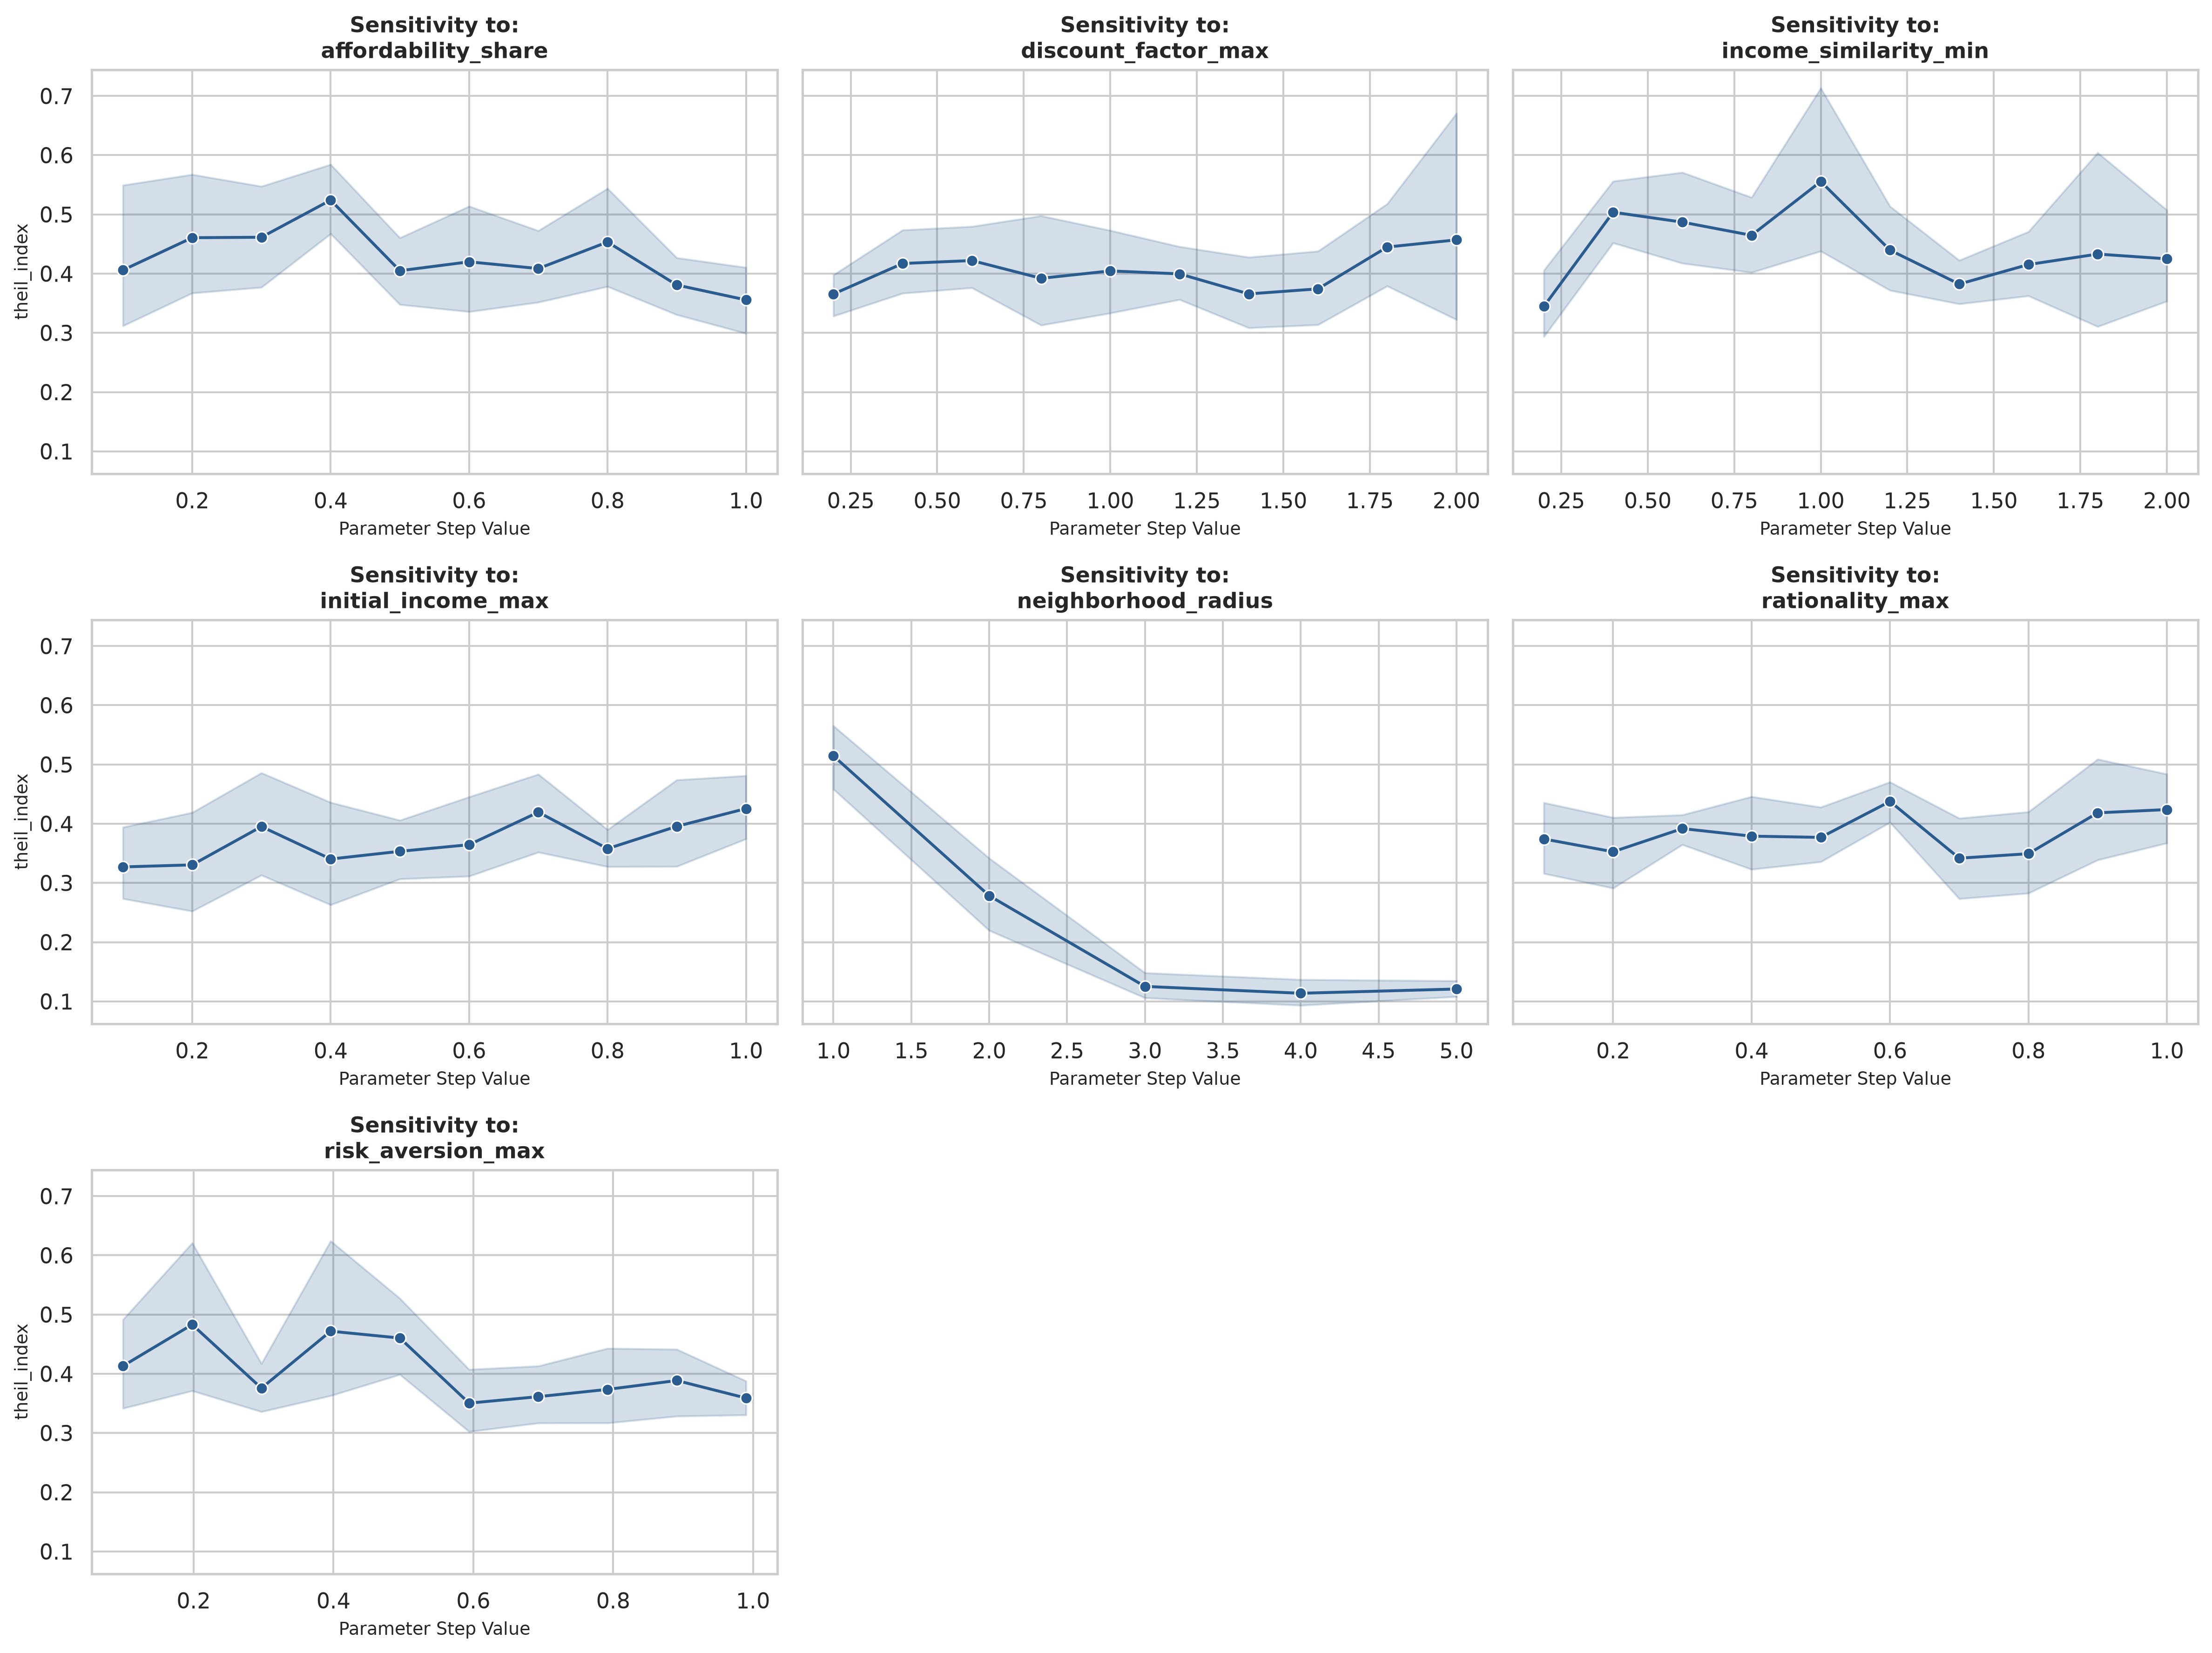

Pipeline executed successfully. Visualization stored at: ofat_sensitivity_analysis_theil_index.png


In [7]:
unique_params = df_master["parameter"].unique()
num_plots = len(unique_params)

# Dynamic grid generation (3 columns wide layout)
cols = 3
rows = (num_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), sharey=True)
axes = axes.flatten()

for idx, param in enumerate(unique_params):
    ax = axes[idx]
    param_subset = df_master[df_master["parameter"] == param]

    # Lineplot aggregates the 10 runs per step into a mean line + 95% CI band
    sns.lineplot(
        data=param_subset,
        x="value",
        y="metric_value",
        ax=ax,
        marker="o",
        color="#2b5c8f",
        errorbar="ci"
    )

    ax.set_title(f"Sensitivity to:\n{param}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Parameter Step Value", fontsize=9)
    ax.set_ylabel(TARGET_METRIC if idx % cols == 0 else "", fontsize=9)

# Clean up any empty grids
for empty_idx in range(idx + 1, len(axes)):
    fig.delaxes(axes[empty_idx])

plt.tight_layout()

# Save output to disk and display within the notebook interface
plt.savefig(OUTPUT_IMAGE, dpi=300)
plt.show()
print(f"Pipeline executed successfully. Visualization stored at: {OUTPUT_IMAGE}")

In [8]:
# Discover and index all available agent file paths across stochastic runs
agent_files = sorted(glob.glob(AGENT_FILE_PATTERN))

print(f"Status: OK")
print(f"Target Pattern: {AGENT_FILE_PATTERN}")
print(f"Found {len(agent_files)} micro-data targets for percentile-group aggregation.")

Status: OK
Target Pattern: ../../ofat_results/risk_aversion_max/0.99/run_*/agents_run_*.csv
Found 10 micro-data targets for percentile-group aggregation.


In [9]:
all_run_matrices = []

for file_path in agent_files:
    df_agents = pd.read_csv(file_path)

    initial_step = df_agents["Step"].min()
    final_step = df_agents["Step"].max()

    # Isolate boundary states
    df_initial = df_agents[df_agents["Step"] == initial_step][["AgentID", "initial_income"]].copy()
    df_final = df_agents[df_agents["Step"] == final_step][["AgentID", "income"]].copy()

    # Determine initial percentile ranks relative to this specific run
    df_initial["Initial Quantile"] = pd.qcut(
        df_initial["initial_income"], q=NUM_QUANTILES, labels=QUANTILE_LABELS, duplicates="drop"
    )

    # Determine global final quantile thresholds for this run's ending distribution
    df_final["Final Quantile"] = pd.qcut(
        df_final["income"], q=NUM_QUANTILES, labels=QUANTILE_LABELS, duplicates="drop"
    )

    # Track groups across time bounds
    df_mobility = pd.merge(df_initial, df_final, on="AgentID")

    # Construct transition frequency table normalized by row
    run_matrix = pd.crosstab(
        df_mobility["Initial Quantile"], df_mobility["Final Quantile"], normalize="index"
    )

    # Reindex to guarantee full shape dimensions match even if a bin was empty
    run_matrix = run_matrix.reindex(index=QUANTILE_LABELS, columns=QUANTILE_LABELS, fill_value=0.0)
    all_run_matrices.append(run_matrix)

print(f"Processed {len(all_run_matrices)} independent transition configurations.")

Processed 10 independent transition configurations.


In [10]:
# Stack along a new structural axis and calculate the mean matrix array
stacked_arrays = np.stack([m.values for m in all_run_matrices], axis=0)
mean_array = np.mean(stacked_arrays, axis=0)

df_aggregate_matrix = pd.DataFrame(
    mean_array,
    index=QUANTILE_LABELS,
    columns=QUANTILE_LABELS
)

print("--- AGGREGATED SYSTEM TRANSITION MATRIX ---")
df_aggregate_matrix

--- AGGREGATED SYSTEM TRANSITION MATRIX ---


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
Q1,0.091667,0.108333,0.116667,0.091667,0.141667,0.083333,0.050000,0.133333,0.116667,0.066667
Q2,0.069697,0.096212,0.078788,0.161364,0.148485,0.103788,0.096212,0.089394,0.060606,0.095455
Q3,0.071970,0.114394,0.107576,0.116667,0.097727,0.115909,0.125000,0.071970,0.062879,0.115909
Q4,0.109091,0.083333,0.092424,0.101515,0.101515,0.104545,0.067424,0.111364,0.102273,0.126515
Q5,0.079545,0.125758,0.079545,0.053030,0.124242,0.143939,0.090152,0.115909,0.115152,0.072727
Q6,0.112121,0.112879,0.115152,0.085606,0.070455,0.124242,0.114394,0.114394,0.097727,0.053030
Q7,0.095455,0.114394,0.076515,0.103788,0.062121,0.106061,0.142424,0.088636,0.078030,0.132576
Q8,0.127273,0.062121,0.103030,0.096212,0.060606,0.112121,0.086364,0.068939,0.084091,0.199242
Q9,0.163636,0.072727,0.063636,0.100000,0.036364,0.081818,0.118182,0.118182,0.118182,0.127273
Q10,0.116667,0.100000,0.133333,0.116667,0.125000,0.025000,0.108333,0.100000,0.116667,0.058333


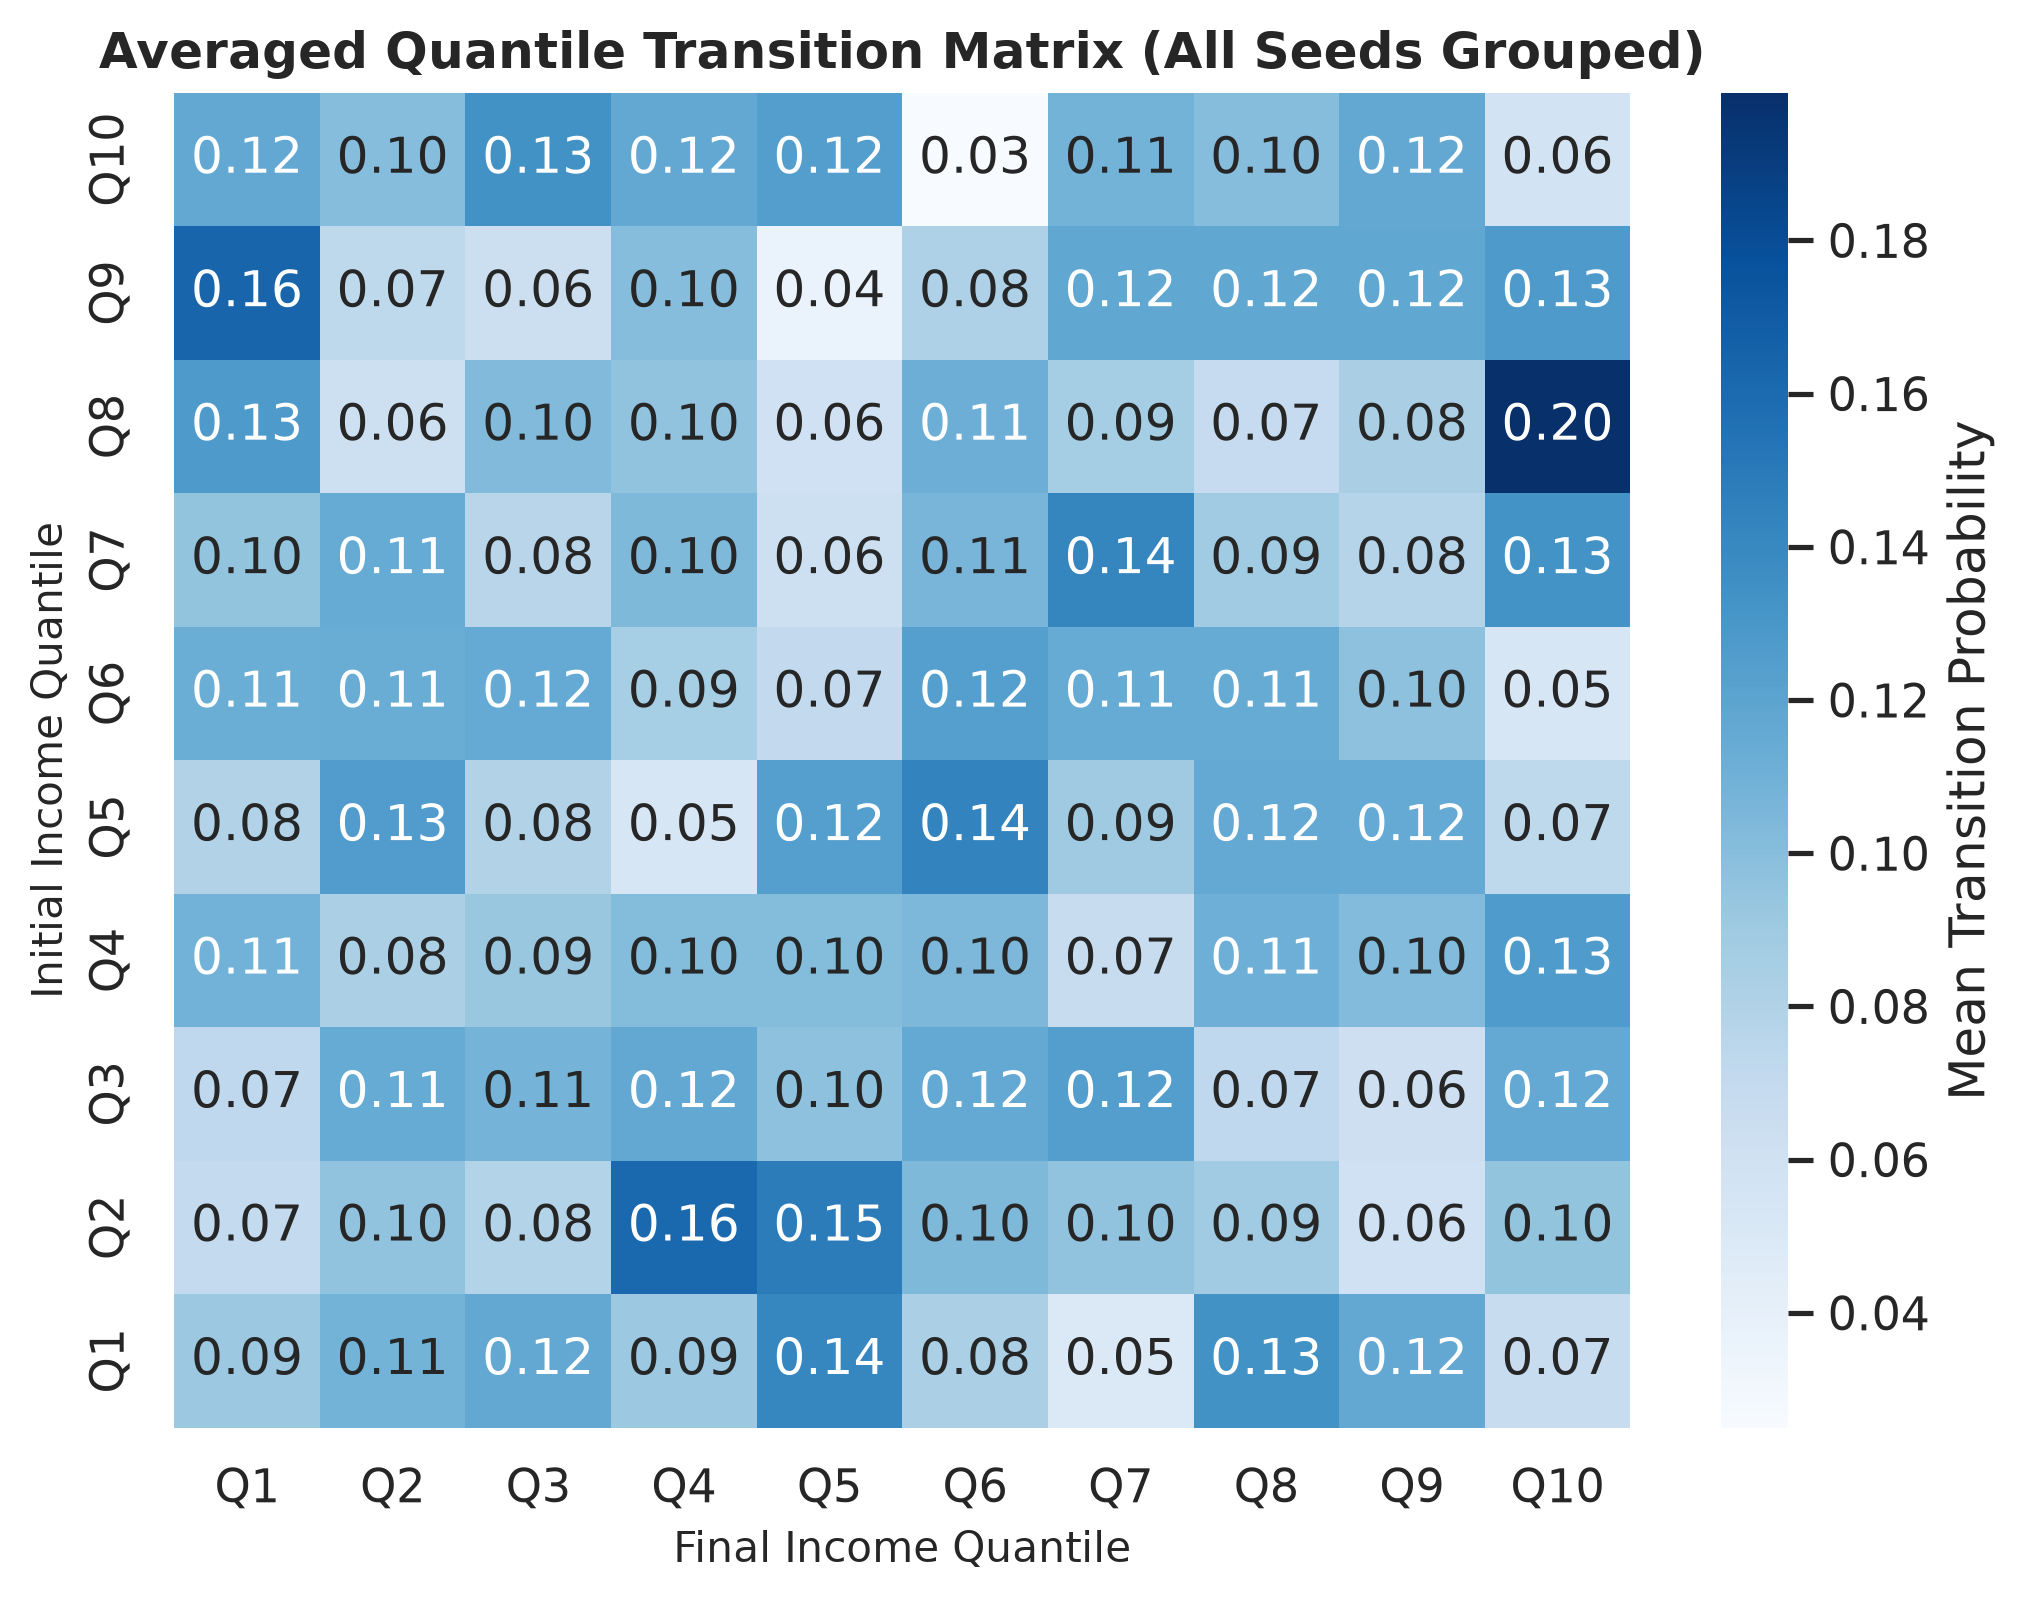

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    df_aggregate_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    cbar_kws={'label': 'Mean Transition Probability'},
    ax=ax
)

ax.invert_yaxis()  # Put Q1 (lowest earners) at the bottom left origin
ax.set_title("Averaged Quantile Transition Matrix (All Seeds Grouped)", fontweight='bold', fontsize=12)
ax.set_xlabel("Final Income Quantile", fontsize=10)
ax.set_ylabel("Initial Income Quantile", fontsize=10)

plt.tight_layout()
plt.show()

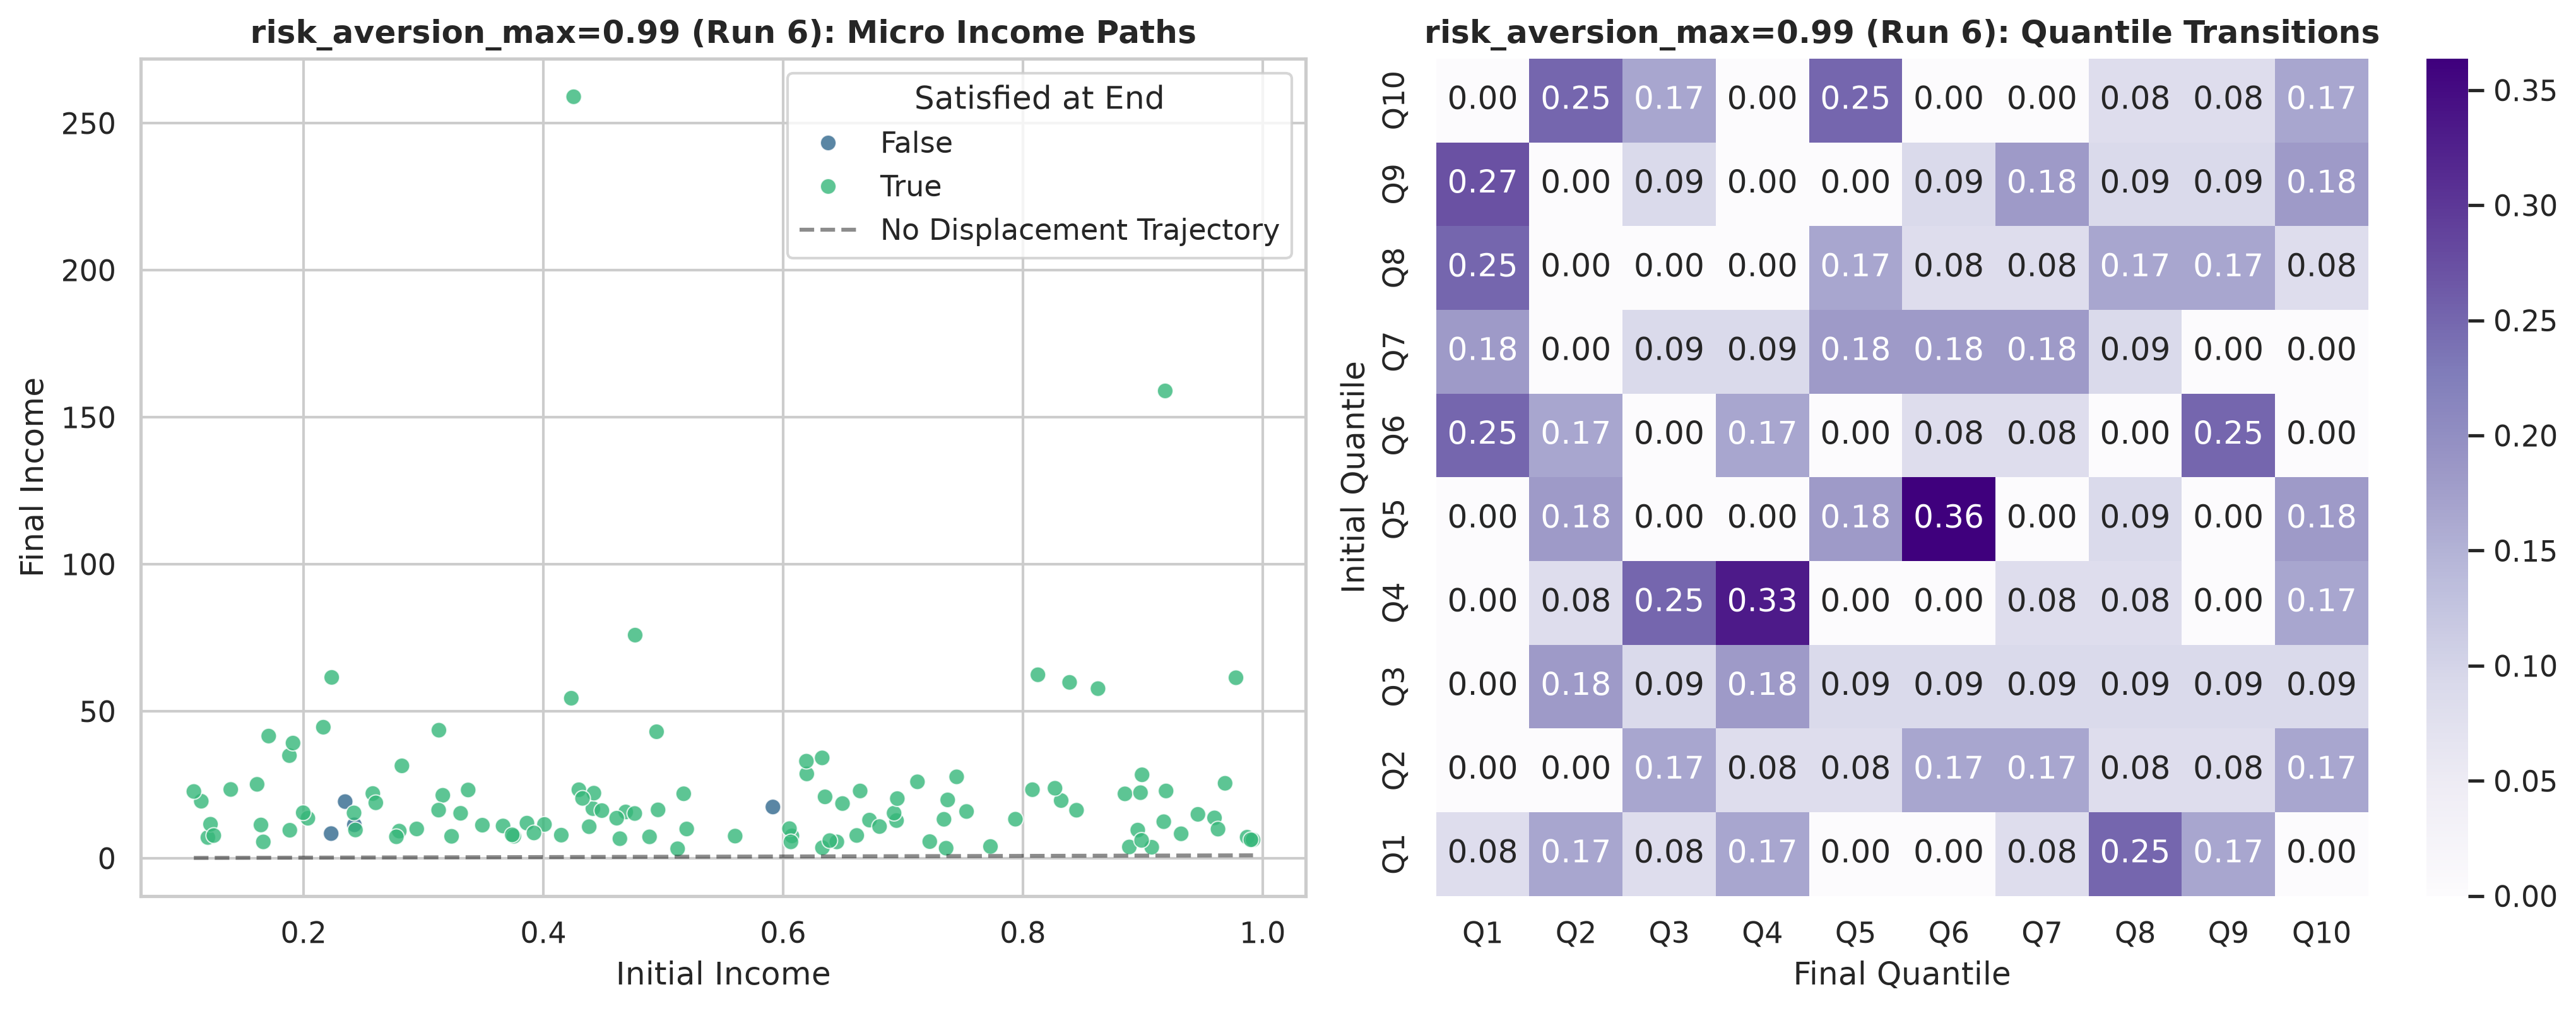

In [12]:
# --- Local Case Study Context ---
# Choose which specific stochastic run seed to isolate for the snapshot comparison
RUN_CHOICE = "6"

# Construct the explicit path descriptor using the parameter context from Cell 2
SINGLE_RUN_FILE = Path(
    f"../../ofat_results/{TARGET_PARAM_NAME}/{TARGET_PARAM_VALUE}/run_{RUN_CHOICE}/agents_run_{RUN_CHOICE}.csv"
)

# Process the targeted case-study dataset
df_single = pd.read_csv(SINGLE_RUN_FILE)
t_init, t_final = df_single["Step"].min(), df_single["Step"].max()

df_case_init = df_single[df_single["Step"] == t_init][["AgentID", "initial_income"]].copy()
df_case_final = df_single[df_single["Step"] == t_final][["AgentID", "income", "satisfied"]].copy()
df_case_mobility = pd.merge(df_case_init, df_case_final, on="AgentID")

# Setup side-by-side single run diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot A: Absolute Mobility Path Tracking
sns.scatterplot(
    data=df_case_mobility, x="initial_income", y="income",
    hue="satisfied", palette="viridis", alpha=0.8, ax=axes[0]
)

# Add y=x identity line
bounds = [min(df_case_mobility["initial_income"]), max(df_case_mobility["initial_income"])]
axes[0].plot(bounds, bounds, "k--", alpha=0.5, label="No Displacement Trajectory")
axes[0].set_title(f"{TARGET_PARAM_NAME}={TARGET_PARAM_VALUE} (Run {RUN_CHOICE}): Micro Income Paths", fontweight="bold")
axes[0].set_xlabel("Initial Income")
axes[0].set_ylabel("Final Income")
axes[0].legend(title="Satisfied at End")

# Plot B: Single-Run Heatmap
df_case_mobility["Init Q"] = pd.qcut(df_case_mobility["initial_income"], q=NUM_QUANTILES, labels=QUANTILE_LABELS)
df_case_mobility["Final Q"] = pd.qcut(df_case_mobility["income"], q=NUM_QUANTILES, labels=QUANTILE_LABELS)
single_matrix = pd.crosstab(
    df_case_mobility["Init Q"], df_case_mobility["Final Q"], normalize="index"
).reindex(index=QUANTILE_LABELS, columns=QUANTILE_LABELS, fill_value=0.0)

sns.heatmap(single_matrix, annot=True, cmap="Purples", fmt=".2f", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title(f"{TARGET_PARAM_NAME}={TARGET_PARAM_VALUE} (Run {RUN_CHOICE}): Quantile Transitions", fontweight="bold")
axes[1].set_xlabel("Final Quantile")
axes[1].set_ylabel("Initial Quantile")

plt.tight_layout()
plt.show()

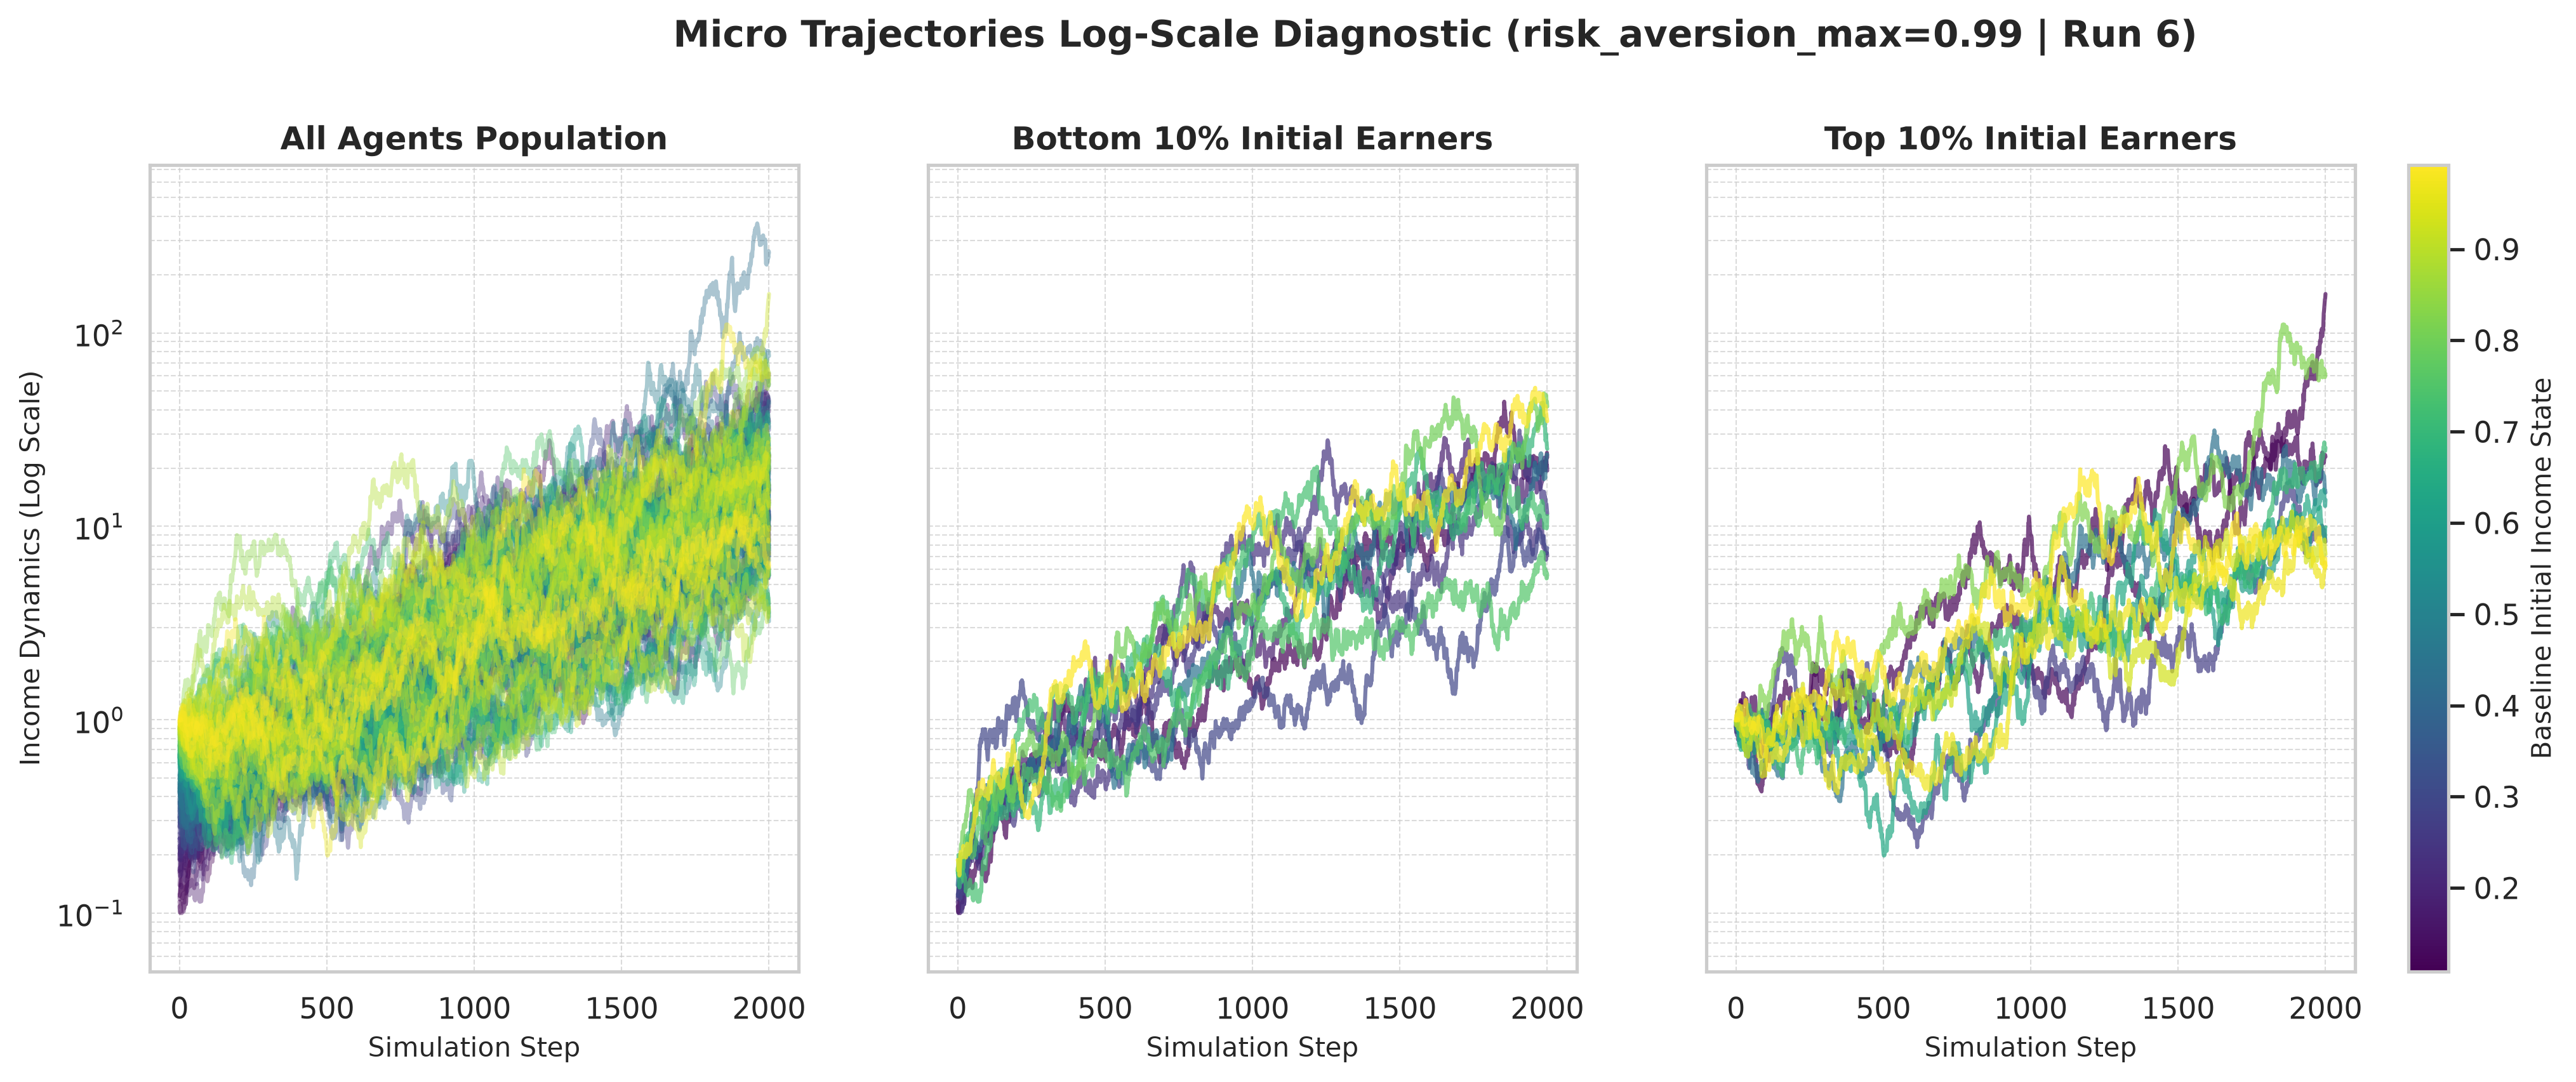

In [15]:
# --- Process Time-Series Trajectories ---
# Use the same SINGLE_RUN_FILE dataset loaded in Cell 12
df_initial_states = df_single[df_single["Step"] == t_init].copy()

# Sort agents to determine thresholds for bottom 10% and top 10%
df_sorted = df_initial_states.sort_values(by="initial_income")
num_agents = len(df_sorted)
k_10_percent = max(1, int(num_agents * 0.10))

# Extract specific AgentID sets
bottom_10_percent_ids = df_sorted.head(k_10_percent)["AgentID"].values
top_10_percent_ids = df_sorted.tail(k_10_percent)["AgentID"].values

# Set up a 3-panel trajectory diagnostic layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

# Define global log-safe Y bounds (using positive scale limits to prevent log(0) errors)
y_min_val = max(1e-3, df_single["income"].min())
Y_MIN, Y_MAX = y_min_val * 0.5, df_single["income"].max() * 2.0
COLOR_MAP = "viridis"

# Panel 1: Complete System Population Trajectories
sns.lineplot(
    data=df_single, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.4, ax=axes[0]
)
axes[0].set_title("All Agents Population", fontweight="bold")
axes[0].get_legend().remove()

# Panel 2: Bottom 10% Initial Earner Trajectories
df_bottom_pop = df_single[df_single["AgentID"].isin(bottom_10_percent_ids)]
sns.lineplot(
    data=df_bottom_pop, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.7, ax=axes[1]
)
axes[1].set_title("Bottom 10% Initial Earners", fontweight="bold")
axes[1].get_legend().remove()

# Panel 3: Top 10% Initial Earner Trajectories
df_top_pop = df_single[df_single["AgentID"].isin(top_10_percent_ids)]
sm = plt.cm.ScalarMappable(
    cmap=COLOR_MAP,
    norm=plt.Normalize(df_single["initial_income"].min(), df_single["initial_income"].max())
)

sns.lineplot(
    data=df_top_pop, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.7, ax=axes[2]
)
axes[2].set_title("Top 10% Initial Earners", fontweight="bold")
axes[2].get_legend().remove()

# Format layout, map log transform, and enable minor gridlines for geometric tracking
for ax in axes:
    ax.set_yscale("log")  # Inject logarithmic transformation stream
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xlabel("Simulation Step", fontsize=10)
    # Major and minor grid lines help track exponential scaling steps
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

axes[0].set_ylabel("Income Dynamics (Log Scale)", fontsize=10)

# Add colorbar matching baseline thresholds
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=20)
cbar.set_label("Baseline Initial Income State", fontsize=10)

plt.suptitle(f"Micro Trajectories Log-Scale Diagnostic ({TARGET_PARAM_NAME}={TARGET_PARAM_VALUE} | Run {RUN_CHOICE})", fontsize=14, fontweight="bold", y=1.02)
plt.show()

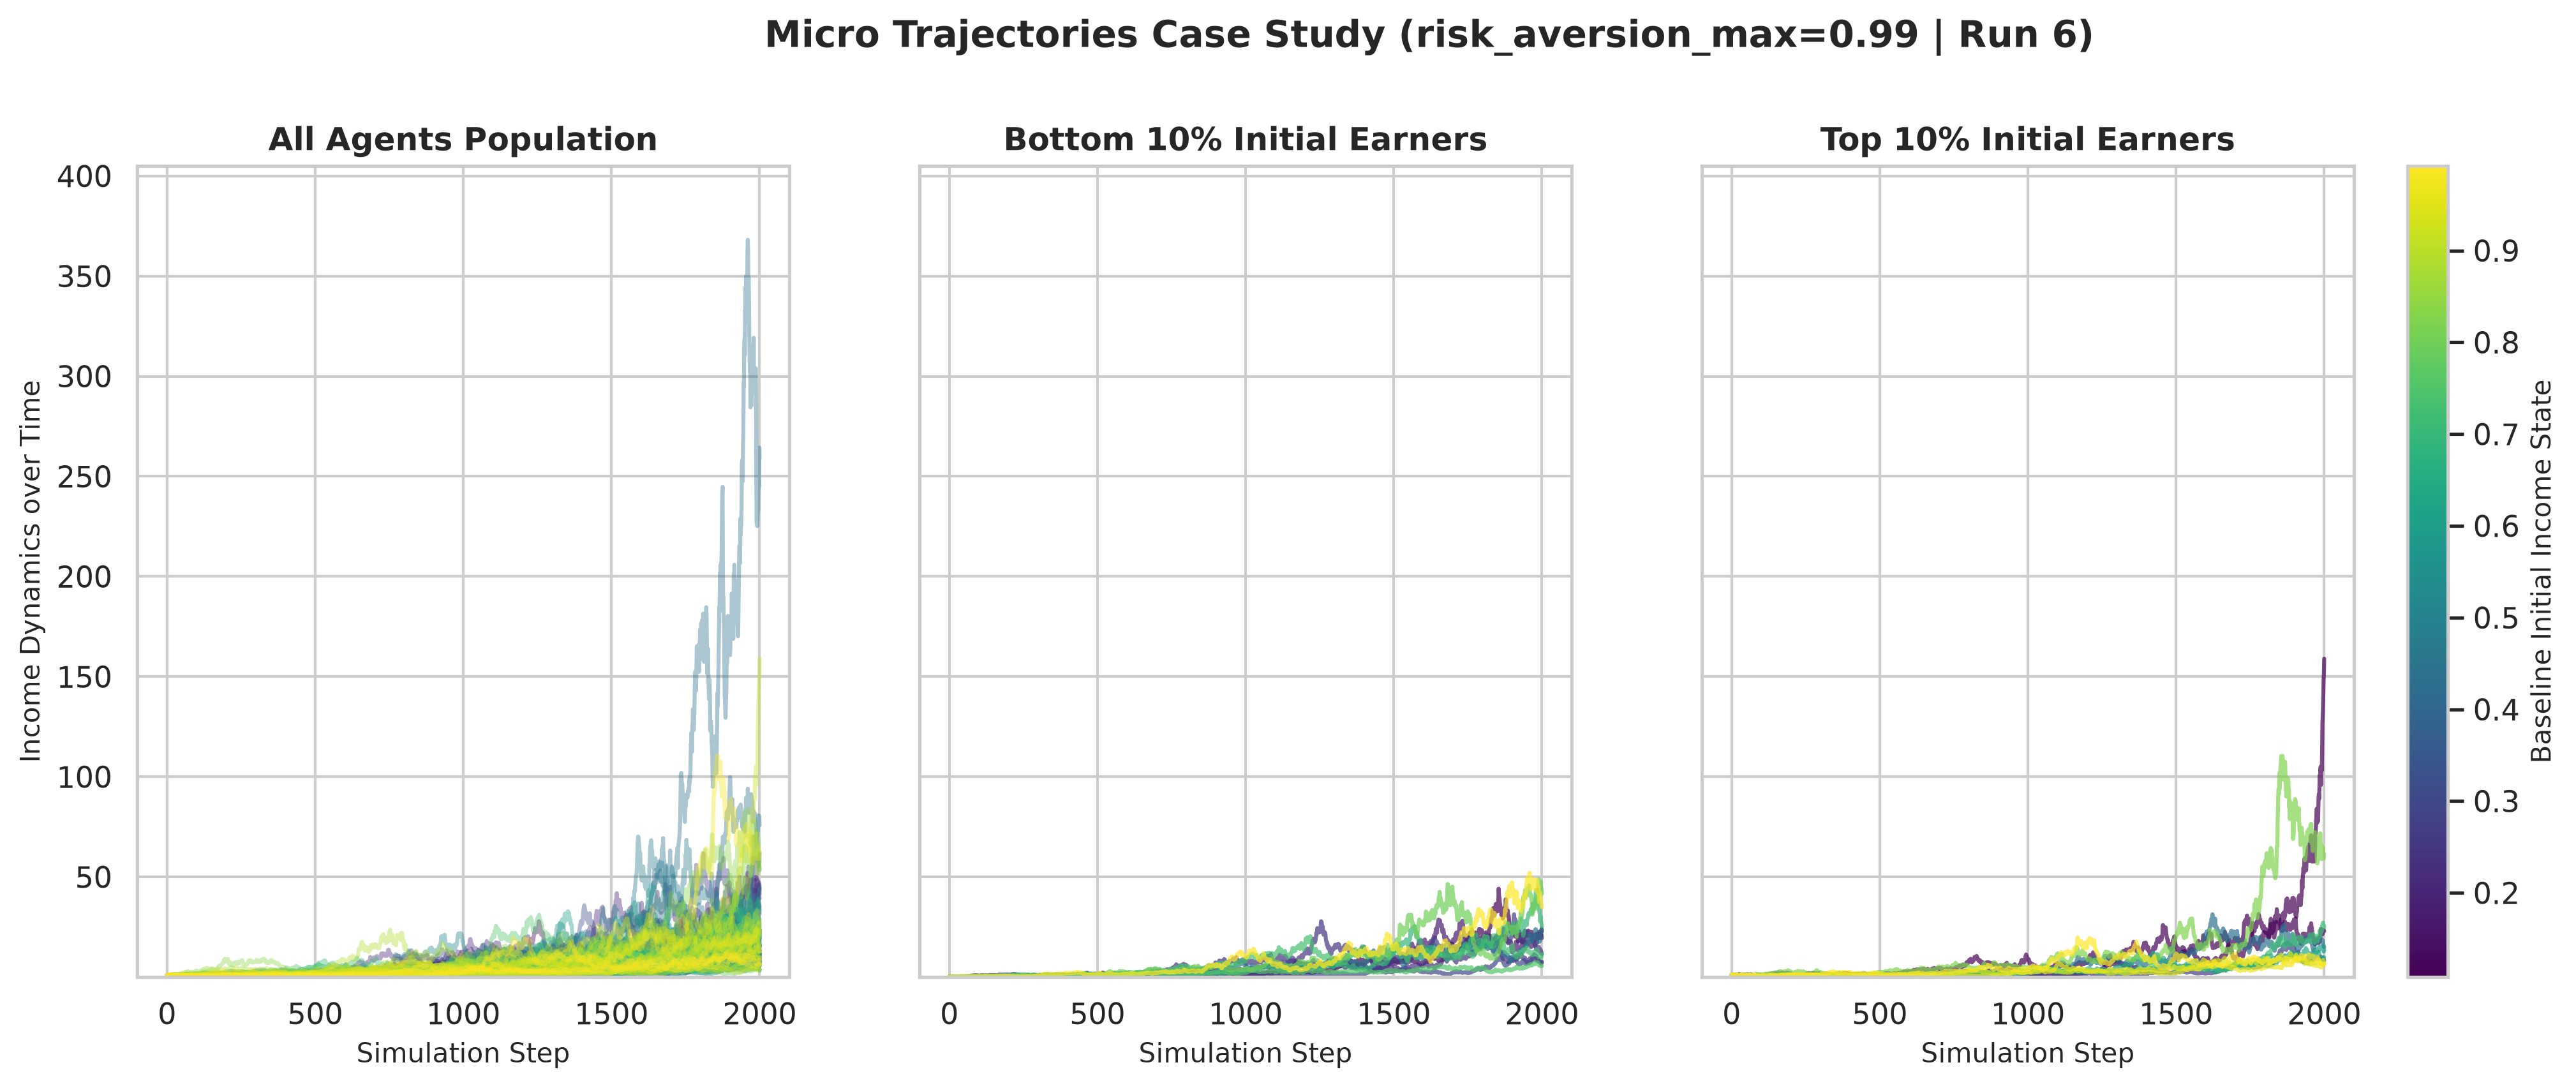

In [16]:
# --- Process Time-Series Trajectories ---
# Use the same SINGLE_RUN_FILE dataset loaded in Cell 12
# Sort agents by initial income to isolate the top and bottom brackets
df_initial_states = df_single[df_single["Step"] == t_init].copy()

# Sort agents to determine thresholds for bottom 10% and top 10%
df_sorted = df_initial_states.sort_values(by="initial_income")
num_agents = len(df_sorted)
k_10_percent = max(1, int(num_agents * 0.10))

# Extract specific AgentID sets
bottom_10_percent_ids = df_sorted.head(k_10_percent)["AgentID"].values
top_10_percent_ids = df_sorted.tail(k_10_percent)["AgentID"].values

# Set up a 3-panel trajectory diagnostic layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

# Define global Y bounds so you can cleanly compare this figure with other runs later
Y_MIN, Y_MAX = df_single["income"].min() * 0.9, df_single["income"].max() * 1.1
COLOR_MAP = "viridis"

# Panel 1: Complete System Population Trajectories
sns.lineplot(
    data=df_single, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.4, ax=axes[0]
)
axes[0].set_title("All Agents Population", fontweight="bold")
axes[0].get_legend().remove() # Remove heavy colorbar clutter from individual panels

# Panel 2: Bottom 10% Initial Earner Trajectories
df_bottom_pop = df_single[df_single["AgentID"].isin(bottom_10_percent_ids)]
sns.lineplot(
    data=df_bottom_pop, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.7, ax=axes[1]
)
axes[1].set_title("Bottom 10% Initial Earners", fontweight="bold")
axes[1].get_legend().remove()

# Panel 3: Top 10% Initial Earner Trajectories
df_top_pop = df_single[df_single["AgentID"].isin(top_10_percent_ids)]
sm = plt.cm.ScalarMappable(cmap=COLOR_MAP, norm=plt.Normalize(df_single["initial_income"].min(), df_single["initial_income"].max()))

sns.lineplot(
    data=df_top_pop, x="Step", y="income", hue="initial_income",
    units="AgentID", estimator=None, palette=COLOR_MAP, alpha=0.7, ax=axes[2]
)
axes[2].set_title("Top 10% Initial Earners", fontweight="bold")
axes[2].get_legend().remove()

# Format layout, labels, and map a single shared colorbar to the edge of the canvas
for ax in axes:
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xlabel("Simulation Step", fontsize=10)
axes[0].set_ylabel("Income Dynamics over Time", fontsize=10)

# Add clear colorbar to show baseline tracking context
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=20)
cbar.set_label("Baseline Initial Income State", fontsize=10)

plt.suptitle(f"Micro Trajectories Case Study ({TARGET_PARAM_NAME}={TARGET_PARAM_VALUE} | Run {RUN_CHOICE})", fontsize=14, fontweight="bold", y=1.02)
plt.show()